# V0.6-H — Research Jupyter Notebook and Final Feature-Selection Report

## 1. Title and Research Context

V0.6 establishes the classical feature-selection baseline for the PhD project **A Lightweight and Green Blockchain-AI Framework for Secure and Energy-Efficient Supply Chain Management**. It asks whether the existing 43-feature cybersecurity detection pipeline can be reduced without materially degrading controlled attack detection.

This is an **artifact-only research notebook**. V0.6-D validation, V0.6-E locking, V0.6-F final testing, and V0.6-G robustness evaluation are scientifically complete. The notebook reads their immutable CSV/JSON outputs; it does not load raw test data, fit selectors, train models, regenerate attacks, tune thresholds, or make new selection decisions.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def locate_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "results" / "feature_selection").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root containing src/ and results/feature_selection/."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
RESULTS_ROOT = PROJECT_ROOT / "results" / "feature_selection"
FINAL_ROOT = RESULTS_ROOT / "final_test"
ROBUSTNESS_ROOT = RESULTS_ROOT / "robustness"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
pd.set_option("display.precision", 6)
np.set_printoptions(precision=6, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.labelsize": 10})

FILES = {
    "core_runs": RESULTS_ROOT / "core_runs.csv",
    "validation_summary": RESULTS_ROOT / "validation_summary.csv",
    "candidate_selection": RESULTS_ROOT / "candidate_selection.json",
    "validation_preservation": RESULTS_ROOT / "preservation_primary.csv",
    "validation_paired": RESULTS_ROOT / "paired_baseline_comparisons.csv",
    "validation_resources": RESULTS_ROOT / "resource_comparison.csv",
    "selected_set_stability": RESULTS_ROOT / "selected_set_stability.csv",
    "selected_feature_sets": RESULTS_ROOT / "selected_feature_sets.json",
    "leakage_audit": RESULTS_ROOT / "leakage_audit.json",
    "run_metadata": RESULTS_ROOT / "run_metadata.json",
    "validation_lock": RESULTS_ROOT / "validation_lock.json",
    "validation_lock_sidecar": RESULTS_ROOT / "validation_lock.sha256",
    "validation_lock_audit": RESULTS_ROOT / "validation_lock_audit.json",
    "final_runs": FINAL_ROOT / "final_test_runs.csv",
    "final_summary": FINAL_ROOT / "final_test_summary.csv",
    "final_paired": FINAL_ROOT / "final_test_paired_comparison.csv",
    "final_preservation": FINAL_ROOT / "final_test_preservation.csv",
    "final_generalization": FINAL_ROOT / "final_test_generalization.csv",
    "final_resources": FINAL_ROOT / "final_test_resource_summary.csv",
    "final_metadata": FINAL_ROOT / "final_test_metadata.json",
    "final_governance": FINAL_ROOT / "final_test_governance_audit.json",
    "robustness_runs": ROBUSTNESS_ROOT / "robustness_runs.csv",
    "attack_family": ROBUSTNESS_ROOT / "attack_family_summary.csv",
    "attack_rate": ROBUSTNESS_ROOT / "attack_rate_summary.csv",
    "attack_severity": ROBUSTNESS_ROOT / "attack_severity_summary.csv",
    "visibility": ROBUSTNESS_ROOT / "visibility_analysis.csv",
    "classifier_comparison": ROBUSTNESS_ROOT / "classifier_comparison.csv",
    "robustness_preservation": ROBUSTNESS_ROOT / "robustness_preservation.csv",
    "robustness_resources": ROBUSTNESS_ROOT / "resource_comparison.csv",
    "robustness_metadata": ROBUSTNESS_ROOT / "robustness_metadata.json",
    "robustness_governance": ROBUSTNESS_ROOT / "robustness_governance_audit.json",
}

missing = [path.relative_to(PROJECT_ROOT) for path in FILES.values() if not path.is_file()]
if missing:
    raise FileNotFoundError("Required locked V0.6 artifacts are missing: " + ", ".join(map(str, missing)))


def read_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


tables = {name: pd.read_csv(path) for name, path in FILES.items() if path.suffix == ".csv"}
documents = {name: read_json(path) for name, path in FILES.items() if path.suffix == ".json"}
artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": name,
            "repository_relative_path": str(path.relative_to(PROJECT_ROOT)),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for name, path in FILES.items()
    ]
).sort_values("artifact", ignore_index=True)

print(f"Repository root: {PROJECT_ROOT}")
print(f"Required locked artifacts verified: {len(artifact_inventory)}")
display(artifact_inventory[["artifact", "repository_relative_path", "bytes"]])

Repository root: /mnt/e/PhD-Blockchain-AI
Required locked artifacts verified: 31


,artifact,repository_relative_path,bytes
0,attack_family,results/feature_selection/robustness/attack_fa...,318971
1,attack_rate,results/feature_selection/robustness/attack_ra...,155976
2,attack_severity,results/feature_selection/robustness/attack_se...,114406
3,candidate_selection,results/feature_selection/candidate_selection....,4579
4,classifier_comparison,results/feature_selection/robustness/classifie...,65155
5,core_runs,results/feature_selection/core_runs.csv,582678
6,final_generalization,results/feature_selection/final_test/final_tes...,1536
7,final_governance,results/feature_selection/final_test/final_tes...,5808
8,final_metadata,results/feature_selection/final_test/final_tes...,1962
9,final_paired,results/feature_selection/final_test/final_tes...,846


## 2. Relationship to the PhD PRD

V0.6 addresses the PRD requirements for an AI/anomaly-detection pipeline, controlled cybersecurity evaluation, lightweight computing, systematic feature reduction, reproducible validation, and computational-efficiency measurement. It supplies a non-metaheuristic baseline against which later optimization can be compared.

The following remain future work: direct Green AI/electrical-energy evaluation, BPSO, BGWO, hybrid BPSO-BGWO optimization, integrated Blockchain-AI decision architecture, multi-objective optimization, deployment scalability, and final ablation studies. V0.6 therefore supports, but does not complete, the full thesis framework.

## 3. V0.6 Research Question

**Can systematic classical feature selection reduce the dimensionality and computational cost of the supply-chain cybersecurity detection pipeline while preserving acceptable controlled attack-detection performance?**

The question is evaluated separately from future BPSO/BGWO/hybrid optimization. Feature-selection decisions use development validation only; the final test and robustness panels evaluate locked decisions without reopening selection.

## 4. Hypotheses

1. At least one classical method can materially reduce the 43-feature space while satisfying preregistered descriptive preservation margins.
2. Reduced feature spaces can lower selected-input and serialized-model size, although wall time and process RSS may not fall proportionally.
3. Supervised and unsupervised selectors will exhibit different stability because supervised scores depend on seed-specific controlled training attacks.
4. Detection will vary more strongly by attack family and feature visibility than by small feature-count differences.
5. A feature-visible attack is not necessarily detectable: visibility is necessary for attack-induced model response, but it is not sufficient for useful classification.

## 5. Experimental Design

The V0.6-D primary validation matrix comprised 12 feature-selection configurations and five seeds (42-46), giving 60 controlled Decision Tree runs. V0.6-E then locked four semantic roles that collapsed to three unique configurations. V0.6-F evaluated 15 locked final-test cells. V0.6-G evaluated 13 robustness scenarios across three configurations, two classifiers, and five seeds, giving 390 cells.

The assertions below reconstruct these design counts solely from stored records and metadata.

In [2]:
core_runs = tables["core_runs"]
final_runs = tables["final_runs"]
robustness_runs = tables["robustness_runs"]
final_metadata = documents["final_metadata"]
robustness_metadata = documents["robustness_metadata"]

assert len(core_runs) == 60 and set(core_runs["status"]) == {"success"}
assert core_runs["configuration_id"].nunique() == 12
assert sorted(core_runs["seed"].unique().tolist()) == [42, 43, 44, 45, 46]
assert len(final_runs) == 15 and final_metadata["completed_run_count"] == 15
assert len(robustness_runs) == 390 and robustness_metadata["completed_run_count"] == 390
assert robustness_metadata["scenario_count"] == 13

design = pd.DataFrame(
    [
        ["V0.6-D validation", 12, 1, 5, 60],
        ["V0.6-F final test", 3, 1, 5, 15],
        ["V0.6-G robustness", 3, 2, 5, 390],
    ],
    columns=["stage", "configurations", "classifiers", "seeds", "verified_runs"],
)
display(design)

,stage,configurations,classifiers,seeds,verified_runs
0,V0.6-D validation,12,1,5,60
1,V0.6-F final test,3,1,5,15
2,V0.6-G robustness,3,2,5,390


## 6. Dataset and Frozen Split

The experiment uses the real DataCo Smart Supply Chain operational table after the frozen V0.2 preprocessing and split protocol: 28,000 training rows, 6,000 development-validation rows, and 6,000 final-test rows. This notebook does not open those data files. Dataset identity, row separation, candidate-feature identity, and attack-manifest identity are taken from the persisted V0.6 governance artifacts.

Uncertainty is limited to five algorithm/attack seeds on one fixed dataset split; it does not represent cross-dataset or cross-organization generalization.

In [3]:
lock = documents["validation_lock"]
dataset_evidence = pd.DataFrame(
    {
        "item": [
            "candidate feature manifest SHA-256",
            "final-test dataset metadata SHA-256",
            "final-test rows per run",
            "attacked rows per primary run",
            "frozen seeds",
        ],
        "artifact_value": [
            lock["candidate_manifest_hash"],
            final_metadata["processed_dataset_metadata_sha256"],
            int(final_runs["evaluated_records"].iloc[0]),
            int(final_runs["attacked_records"].iloc[0]),
            ", ".join(map(str, robustness_metadata["seeds"])),
        ],
    }
)
display(dataset_evidence)

,item,artifact_value
0,candidate feature manifest SHA-256,5146fd08fe766979adaf443bf9f4f7d32ee3c94cfdaf0f...
1,final-test dataset metadata SHA-256,139f84f1443c39ff8b5a9c114b54a6a69ce177bf6f1a3d...
2,final-test rows per run,6000
3,attacked rows per primary run,300
4,frozen seeds,"42, 43, 44, 45, 46"


## 7. Feature Space

The candidate manifest contains 43 leakage-controlled engineered inputs spanning order quantity/value, pricing, temporal variables, order aggregates, payment type, market, shipping mode, customer segment, and department indicators. The full baseline means this 43-feature candidate manifest, not every raw DataCo field.

The locked configurations retain 43, 42, and 11 features. The 43-to-11 reduction is computed from the artifacts below rather than hard-coded.

In [4]:
validation_summary = tables["validation_summary"]
locked_ids = [
    "none_natural",
    "pairwise_correlation_filter_natural",
    "mutual_information_select_k_best_k11",
]
labels = {
    "none_natural": "Full baseline",
    "pairwise_correlation_filter_natural": "Pairwise correlation",
    "mutual_information_select_k_best_k11": "MI K=11",
}

locked_validation = validation_summary[validation_summary["configuration_id"].isin(locked_ids)].copy()
locked_validation["configuration"] = locked_validation["configuration_id"].map(labels)
feature_counts = locked_validation.set_index("configuration_id")["feature_count_mean"]
feature_reduction = 100.0 * (
    feature_counts["none_natural"] - feature_counts["mutual_information_select_k_best_k11"]
) / feature_counts["none_natural"]

assert feature_counts["none_natural"] == 43
assert feature_counts["pairwise_correlation_filter_natural"] == 42
assert feature_counts["mutual_information_select_k_best_k11"] == 11
assert np.isclose(feature_reduction, 74.4186046511628)

display(
    locked_validation[
        ["configuration", "selector_type", "feature_count_mean", "average_precision_mean", "f1_mean", "recall_mean"]
    ].sort_values("feature_count_mean", ascending=False)
)
print(f"Verified feature reduction, 43 -> 11: {feature_reduction:.2f}%")

,configuration,selector_type,feature_count_mean,average_precision_mean,f1_mean,recall_mean
0,Full baseline,none,43.0,0.230684,0.197701,0.322000
2,Pairwise correlation,unsupervised,42.0,0.230684,0.197701,0.322000
8,MI K=11,supervised,11.0,0.232628,0.205610,0.316667


Verified feature reduction, 43 -> 11: 74.42%


## 8. Cybersecurity Ground Truth

DataCo does not provide native cyberattack labels. V0.6 uses controlled attack manifestations created by the established V0.4 generator, with `is_attack` defined before inference. These labels are experimental ground truth for controlled data-tampering scenarios, not evidence of real-world intrusions.

Attack metadata, selected row identifiers, original/modified values, and experimental labels remain outside model inputs. The seven single-family scenarios are quantity, value, shipping/delivery, transaction status, timestamp, geographic route, and transaction-record tampering.

In [5]:
attack_family = tables["attack_family"]
families = sorted(attack_family["attack_type"].dropna().unique().tolist())
assert len(families) == 7
display(pd.DataFrame({"controlled_attack_family": families}))

,controlled_attack_family
0,geographic_route_manipulation
1,quantity_manipulation
2,shipping_delivery_manipulation
3,timestamp_manipulation
4,transaction_record_tampering
5,transaction_status_manipulation
6,value_manipulation


## 9. Leakage-Control Protocol

Unsupervised selectors received no labels. Supervised MI and ANOVA-F selectors used only controlled training `is_attack` labels. Preprocessing and selector fitting were confined to training data. Validation supported the preregistered lock; final-test data did not influence feature selection, model fitting, threshold selection, or attack configuration.

The audit is executable evidence: every persisted leakage check must pass.

In [6]:
leakage_audit = documents["leakage_audit"]
leakage_checks = pd.DataFrame(leakage_audit["checks"])
assert leakage_audit["status"] == "PASS"
assert leakage_checks["passed"].all()
assert not leakage_audit["test_accessed"]

important_checks = [
    "test_accessed",
    "validation_only_evaluation",
    "exact_frozen_seeds",
    "train_validation_rows_disjoint",
    "selectors_fitted_on_training_only",
    "supervised_selectors_use_training_ground_truth_only",
    "unsupervised_selectors_ignore_labels",
]
display(leakage_checks[leakage_checks["name"].isin(important_checks)][["name", "passed"]])
print(f"Leakage audit: {leakage_audit['status']} ({len(leakage_checks)} checks)")

,name,passed
0,test_accessed,True
2,validation_only_evaluation,True
3,exact_frozen_seeds,True
8,train_validation_rows_disjoint,True


Leakage audit: PASS (26 checks)


## 10. Classical Feature-Selection Methods

V0.6 deliberately precedes metaheuristic optimization. It evaluates:

- No-selection control.
- Zero-variance threshold.
- Pairwise-correlation filtering.
- Correlation-redundancy ranking.
- Supervised mutual information (`SelectKBest`).
- Supervised ANOVA F-statistic (`SelectKBest`).

RFE was optional and was not included in the frozen core. BPSO, BGWO, hybrids, NSGA-II, and MOPSO were explicitly excluded.

In [7]:
method_inventory = (
    validation_summary[
        ["selector_id", "selector_type", "count_strategy", "configuration_id", "feature_count_mean"]
    ]
    .sort_values(["selector_type", "selector_id", "feature_count_mean"], ascending=[True, True, False])
    .reset_index(drop=True)
)
display(method_inventory)

,selector_id,selector_type,count_strategy,configuration_id,feature_count_mean
0,none,none,natural,none_natural,43.0
1,anova_f_select_k_best,supervised,fixed_k,anova_f_select_k_best_k32,32.0
2,anova_f_select_k_best,supervised,fixed_k,anova_f_select_k_best_k22,22.0
3,anova_f_select_k_best,supervised,fixed_k,anova_f_select_k_best_k11,11.0
4,mutual_information_select_k_best,supervised,fixed_k,mutual_information_select_k_best_k32,32.0
5,mutual_information_select_k_best,supervised,fixed_k,mutual_information_select_k_best_k22,22.0
6,mutual_information_select_k_best,supervised,fixed_k,mutual_information_select_k_best_k11,11.0
7,correlation_redundancy_ranking,unsupervised,fixed_k,correlation_redundancy_ranking_k32,32.0
8,correlation_redundancy_ranking,unsupervised,fixed_k,correlation_redundancy_ranking_k22,22.0
9,correlation_redundancy_ranking,unsupervised,fixed_k,correlation_redundancy_ranking_k11,11.0


## 11. Feature-Count Configurations

Fixed K values 32, 22, and 11 approximate 75%, 50%, and 25% retention from 43 candidates. Natural-count methods retain however many features their rule permits. This separates selector behavior from an arbitrary single K and provides matched count levels across ranking methods.

The final lock does not imply that every 11-feature method worked: correlation-ranking K11 and ANOVA-F K11 did not satisfy the primary preservation rule, whereas MI K11 did.

## 12. Primary Decision Tree Configuration

The primary controlled model is the V0.5 Decision Tree: `max_depth=5`, `min_samples_leaf=20`, `class_weight="balanced"`, and `random_state=seed`, with decision threshold 0.5. Keeping one model fixed isolates feature-selection effects. Its small serialized form and transparent capacity also fit the lightweight-computing objective.

In [8]:
model_params = json.loads(core_runs["model_parameters_json"].iloc[0])
assert model_params["max_depth"] == 5
assert model_params["min_samples_leaf"] == 20
assert model_params["class_weight"] == "balanced"
assert set(core_runs["prediction_threshold"]) == {0.5}
display(pd.Series(model_params, name="frozen Decision Tree value").to_frame())

,frozen Decision Tree value
class_weight,balanced
max_depth,5
min_samples_leaf,20


## 13. Secondary Logistic Regression Configuration

V0.6-G adds an untuned linear comparator using `solver="liblinear"`, `class_weight="balanced"`, `max_iter=500`, `C=1.0`, and seed-specific `random_state`, again at threshold 0.5. Logistic Regression was fitted once per seed/configuration on controlled training labels and reused across robustness scenarios. It is secondary evidence, not a replacement model selected from final-test outcomes.

In [9]:
lr_params = robustness_metadata["lr_parameters"]
assert lr_params == {
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 500,
    "random_state": "seed",
    "solver": "liblinear",
}
assert robustness_metadata["logistic_fit_count"] == 15
display(pd.Series(lr_params, name="frozen Logistic Regression value").to_frame())

,frozen Logistic Regression value
C,1.0
class_weight,balanced
max_iter,500
random_state,seed
solver,liblinear


## 14. Validation Experiment

Selection used five-seed development-validation means. The primary descriptive rule allowed at most 5% relative degradation in average precision (AP) and F1 and at most 10% in recall. This is a margin-based descriptive screen, not a formal statistical non-inferiority trial.

MI K11 achieved the strongest reduction among preserving candidates. Pairwise correlation preserved baseline predictions while removing one redundant feature. Confidence intervals for MI K11 paired metric differences cross zero, so the evidence supports preservation, not statistically established improvement.

,configuration,feature_count_mean,average_precision_mean,f1_mean,recall_mean
0,Full baseline,43.0,0.230684,0.197701,0.322000
2,Pairwise correlation,42.0,0.230684,0.197701,0.322000
8,MI K=11,11.0,0.232628,0.205610,0.316667


,configuration_id,average_precision_difference_mean,average_precision_difference_ci95_low,average_precision_difference_ci95_high,f1_difference_mean,f1_difference_ci95_low,f1_difference_ci95_high,recall_difference_mean,recall_difference_ci95_low,recall_difference_ci95_high
1,pairwise_correlation_filter_natural,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,mutual_information_select_k_best_k11,0.001944,-0.005582,0.00947,0.007909,-0.048917,0.064735,-0.005333,-0.029924,0.019257


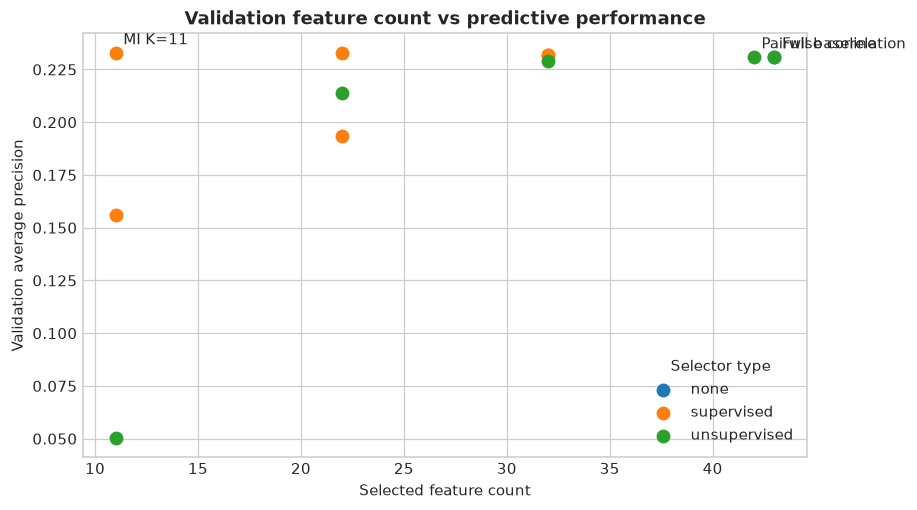

In [10]:
validation_paired = tables["validation_paired"]
validation_preservation = tables["validation_preservation"]
candidate_selection = documents["candidate_selection"]

mi_validation_pair = validation_paired[
    validation_paired["configuration_id"] == "mutual_information_select_k_best_k11"
].iloc[0]
for metric in ["average_precision", "f1", "recall"]:
    assert mi_validation_pair[f"{metric}_difference_ci95_low"] <= 0 <= mi_validation_pair[f"{metric}_difference_ci95_high"]
assert candidate_selection["best_supervised"]["configuration_id"] == "mutual_information_select_k_best_k11"
assert candidate_selection["best_unsupervised"]["configuration_id"] == "pairwise_correlation_filter_natural"

validation_results = locked_validation[
    ["configuration", "feature_count_mean", "average_precision_mean", "f1_mean", "recall_mean"]
].copy()
display(validation_results.sort_values("feature_count_mean", ascending=False))
display(
    validation_paired[validation_paired["configuration_id"].isin(locked_ids[1:])][
        [
            "configuration_id",
            "average_precision_difference_mean",
            "average_precision_difference_ci95_low",
            "average_precision_difference_ci95_high",
            "f1_difference_mean",
            "f1_difference_ci95_low",
            "f1_difference_ci95_high",
            "recall_difference_mean",
            "recall_difference_ci95_low",
            "recall_difference_ci95_high",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(8.5, 5))
all_validation = validation_summary.copy()
for selector_type, group in all_validation.groupby("selector_type"):
    ax.scatter(group["feature_count_mean"], group["average_precision_mean"], s=65, label=selector_type)
for _, row in locked_validation.iterrows():
    ax.annotate(labels[row["configuration_id"]], (row["feature_count_mean"], row["average_precision_mean"]), xytext=(5, 6), textcoords="offset points")
ax.set(xlabel="Selected feature count", ylabel="Validation average precision", title="Validation feature count vs predictive performance")
ax.legend(title="Selector type")
plt.show()

## 15. Validation Lock

V0.6-E transformed development-only decisions into an immutable artifact. The lock records the candidate manifest, three unique locked configurations, four semantic roles, per-seed feature fingerprints, model hashes, threshold, attack protocol, source hashes, and the explicit prohibition on reopening selection.

In [11]:
lock_audit = documents["validation_lock_audit"]
sidecar_hash = FILES["validation_lock_sidecar"].read_text(encoding="utf-8").split()[0]
observed_lock_hash = sha256_file(FILES["validation_lock"])
lock_checks = pd.DataFrame(lock_audit["checks"])

assert observed_lock_hash == sidecar_hash
assert lock_audit["status"] == "PASS" and lock_checks["passed"].all()
assert lock["semantic_payload_sha256"] == final_metadata["semantic_lock_sha256"]
assert lock["decision_threshold"] == 0.5

lock_evidence = pd.DataFrame(
    {
        "property": ["file SHA-256", "semantic SHA-256", "audit status", "decision threshold", "locked seeds"],
        "value": [
            observed_lock_hash,
            lock["semantic_payload_sha256"],
            lock_audit["status"],
            lock["decision_threshold"],
            ", ".join(map(str, lock["seeds"])),
        ],
    }
)
display(lock_evidence)

,property,value
0,file SHA-256,71dc92b8a34db1bb3c2f55a69e56f43733544329128ec6...
1,semantic SHA-256,487b7aea89a9998b92e1d6bb6eac87d557a2328db82d82...
2,audit status,PASS
3,decision threshold,0.5
4,locked seeds,"42, 43, 44, 45, 46"


## 16. Final-Test Evaluation

V0.6-F opened the final test only after lock verification. Fifteen runs evaluated the three unique locked configurations across five seeds. No selector, preprocessor, or model was fitted and no decision changed.

MI K11 preserved the preregistered descriptive margins relative to the 43-feature baseline. Its mean AP and F1 were slightly higher and recall slightly lower, but all three paired 95% confidence intervals cross zero. The defensible conclusion is preservation under this experiment, not superiority. Absolute performance remained modest: baseline AP was about 0.222 and MI K11 AP about 0.225.

metric,configuration,features,average_precision,f1,precision,recall,roc_auc
0,Full baseline,43.0,0.222084,0.189005,0.265385,0.305333,0.603533
1,Pairwise correlation,42.0,0.222084,0.189005,0.265385,0.305333,0.603533
2,MI K=11,11.0,0.224941,0.192121,0.293470,0.300000,0.605495


,configuration_id,baseline_configuration_id,metric,paired_seed_count,mean_difference,ci95_low,ci95_high
6,mutual_information_select_k_best_k11,none_natural,average_precision,5,0.002857,-0.007383,0.013097
7,mutual_information_select_k_best_k11,none_natural,f1,5,0.003116,-0.044833,0.051065
8,mutual_information_select_k_best_k11,none_natural,recall,5,-0.005333,-0.037473,0.026806


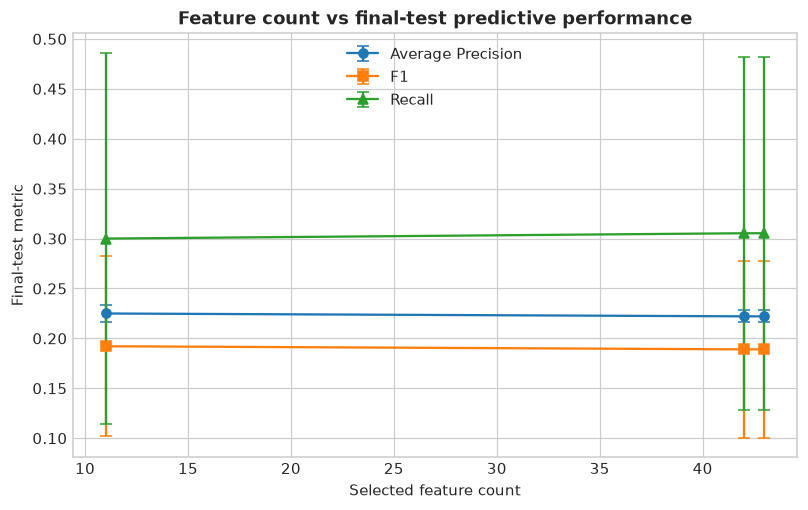

In [12]:
final_summary = tables["final_summary"]
final_paired = tables["final_paired"]
final_preservation = tables["final_preservation"]
final_governance = documents["final_governance"]

final_perf = (
    final_summary[final_summary["metric"].isin(["average_precision", "f1", "recall", "precision", "roc_auc"])]
    .pivot(index="configuration_id", columns="metric", values="mean")
    .loc[locked_ids]
    .reset_index()
)
final_perf.insert(1, "configuration", final_perf["configuration_id"].map(labels))
final_perf.insert(2, "features", final_perf["configuration_id"].map(feature_counts))

mi_final_pair = final_paired[final_paired["configuration_id"] == "mutual_information_select_k_best_k11"]
assert set(mi_final_pair["metric"]) == {"average_precision", "f1", "recall"}
assert ((mi_final_pair["ci95_low"] <= 0) & (mi_final_pair["ci95_high"] >= 0)).all()
mi_preservation = final_preservation[final_preservation["configuration_id"] == "mutual_information_select_k_best_k11"]
assert mi_preservation["descriptively_preserved"].all()
assert mi_preservation["overall_descriptive_preservation"].all()
assert not final_preservation["selection_performed"].any()
assert all(check["passed"] for check in final_governance["checks"])

display(final_perf.drop(columns="configuration_id"))
display(mi_final_pair)

fig, ax = plt.subplots(figsize=(8.5, 5))
metric_markers = {"average_precision": "o", "f1": "s", "recall": "^"}
for metric, marker in metric_markers.items():
    rows = final_summary[final_summary["metric"] == metric].set_index("configuration_id").loc[locked_ids]
    ax.errorbar(
        feature_counts.loc[locked_ids],
        rows["mean"],
        yerr=[rows["mean"] - rows["ci95_low"], rows["ci95_high"] - rows["mean"]],
        marker=marker,
        capsize=4,
        label=metric.replace("_", " ").title(),
    )
ax.set(xlabel="Selected feature count", ylabel="Final-test metric", title="Feature count vs final-test predictive performance")
ax.legend()
plt.show()

## 17. Robustness Evaluation

V0.6-G evaluates seven attack families at 5% MEDIUM, four mixed attack rates (1%, 3%, 5%, 10%) at MEDIUM, and three mixed severities (LOW, MEDIUM, HIGH) at 5%. The primary 5% MEDIUM scenario exactly replays V0.6-F manifestations.

Attack family dominates the Decision Tree response. Quantity manipulation is comparatively detectable, transaction-record tampering is intermediate, and several families are near prevalence-level AP. AP and F1 generally rise with attack rate partly because class prevalence changes; that trend must not be interpreted as an unqualified robustness gain. Severity response is not monotonic.

configuration_id,MI K=11,Full baseline,Pairwise correlation
attack_type,,,
geographic_route_manipulation,0.049658,0.049837,0.049837
quantity_manipulation,0.793351,0.795512,0.795512
shipping_delivery_manipulation,0.049658,0.049837,0.049837
timestamp_manipulation,0.049658,0.049837,0.049837
transaction_record_tampering,0.476365,0.471151,0.471151
transaction_status_manipulation,0.049658,0.049837,0.049837
value_manipulation,0.097398,0.086363,0.086363


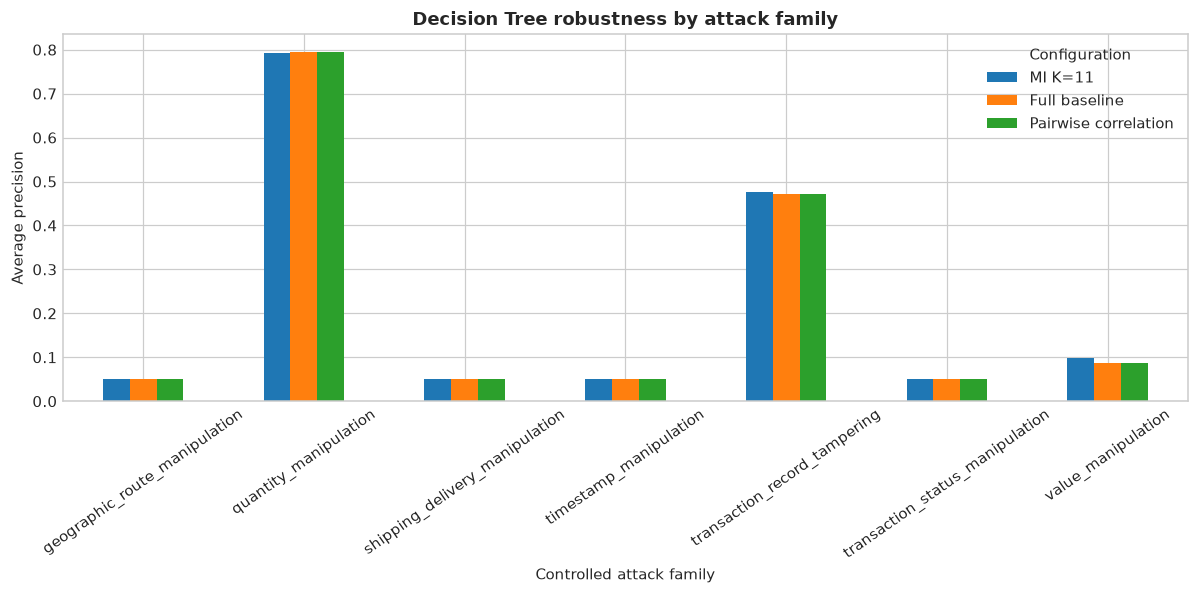

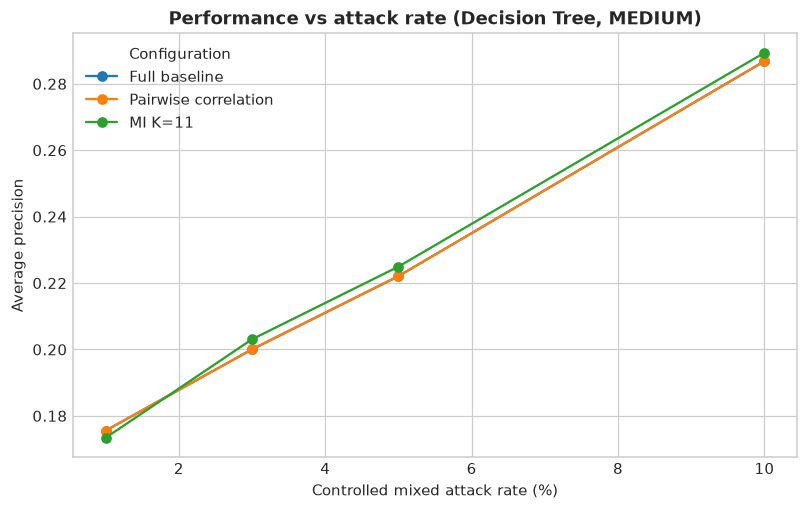

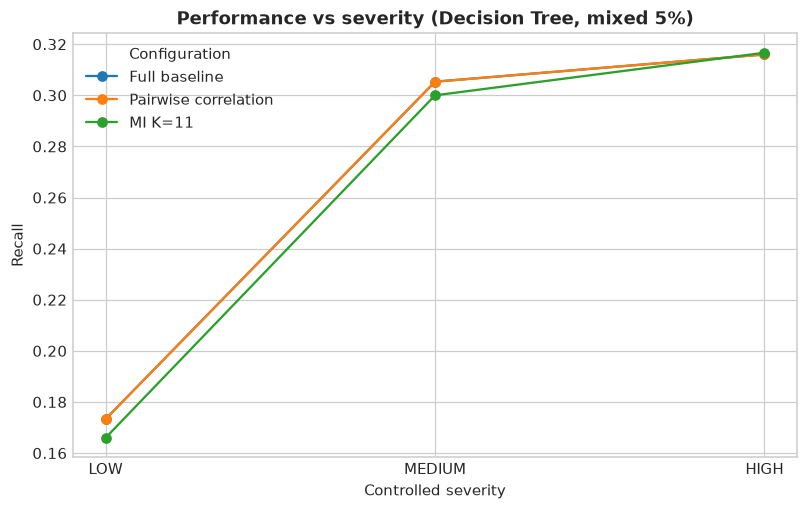

classifier,decision_tree,logistic_regression
metric,,
average_precision,0.222084,0.051150
f1,0.189005,0.087348
recall,0.305333,0.423333


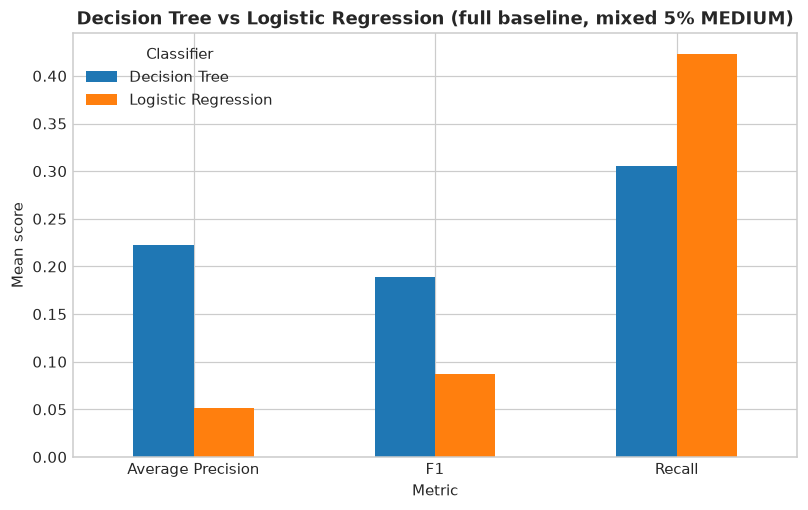

In [13]:
attack_rate = tables["attack_rate"]
attack_severity = tables["attack_severity"]

family_ap = attack_family[
    (attack_family["classifier"] == "decision_tree")
    & (attack_family["metric"] == "average_precision")
    & attack_family["configuration_id"].isin(locked_ids)
].pivot(index="attack_type", columns="configuration_id", values="mean")
display(family_ap.rename(columns=labels))

fig, ax = plt.subplots(figsize=(11, 5.5))
family_ap.rename(columns=labels).plot(kind="bar", ax=ax)
ax.set(xlabel="Controlled attack family", ylabel="Average precision", title="Decision Tree robustness by attack family")
ax.legend(title="Configuration")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

rate_ap = attack_rate[
    (attack_rate["classifier"] == "decision_tree")
    & (attack_rate["metric"] == "average_precision")
    & attack_rate["configuration_id"].isin(locked_ids)
].pivot(index="attack_rate", columns="configuration_id", values="mean")

fig, ax = plt.subplots(figsize=(8.5, 5))
for config in locked_ids:
    ax.plot(rate_ap.index * 100, rate_ap[config], marker="o", label=labels[config])
ax.set(xlabel="Controlled mixed attack rate (%)", ylabel="Average precision", title="Performance vs attack rate (Decision Tree, MEDIUM)")
ax.legend(title="Configuration")
plt.show()

severity_recall = attack_severity[
    (attack_severity["classifier"] == "decision_tree")
    & (attack_severity["metric"] == "recall")
    & attack_severity["configuration_id"].isin(locked_ids)
].copy()
severity_order = ["LOW", "MEDIUM", "HIGH"]
severity_pivot = severity_recall.pivot(index="attack_severity", columns="configuration_id", values="mean").loc[severity_order]

fig, ax = plt.subplots(figsize=(8.5, 5))
for config in locked_ids:
    ax.plot(severity_order, severity_pivot[config], marker="o", label=labels[config])
ax.set(xlabel="Controlled severity", ylabel="Recall", title="Performance vs severity (Decision Tree, mixed 5%)")
ax.legend(title="Configuration")
plt.show()

primary = attack_severity[
    (attack_severity["scenario_id"] == "mixed__r0p05__medium")
    & (attack_severity["configuration_id"] == "none_natural")
    & attack_severity["metric"].isin(["average_precision", "f1", "recall"])
]
classifier_primary = primary.pivot(index="metric", columns="classifier", values="mean").loc[["average_precision", "f1", "recall"]]
display(classifier_primary)

fig, ax = plt.subplots(figsize=(8.5, 5))
classifier_primary.rename(index=lambda value: value.replace("_", " ").title(), columns={"decision_tree": "Decision Tree", "logistic_regression": "Logistic Regression"}).plot(kind="bar", ax=ax)
ax.set(xlabel="Metric", ylabel="Mean score", title="Decision Tree vs Logistic Regression (full baseline, mixed 5% MEDIUM)")
ax.legend(title="Classifier")
ax.tick_params(axis="x", rotation=0)
plt.show()

## 18. Attack Visibility Analysis

Visibility asks whether a controlled source-field modification changes at least one selected engineered model input. Zero visibility means the detector cannot react to the modification through its input matrix; it does not mean the attack is operationally irrelevant.

Quantity, value, timestamp, and generic record tampering are feature-visible to the full 43-feature baseline. Shipping/delivery, status, and geographic-route changes are invisible because their source information was excluded or not represented. Crucially, timestamp manipulation is visible yet remains difficult to detect. Therefore **feature visibility is important/necessary but not sufficient for successful detection**.

,visibility_rate,average_precision
attack_type,,
geographic_route_manipulation,0.0,0.049837
quantity_manipulation,1.0,0.795512
shipping_delivery_manipulation,0.0,0.049837
timestamp_manipulation,1.0,0.049837
transaction_record_tampering,1.0,0.471151
transaction_status_manipulation,0.0,0.049837
value_manipulation,1.0,0.086363


Timestamp example: visibility=1.00, AP=0.0498, recall=0.1493.


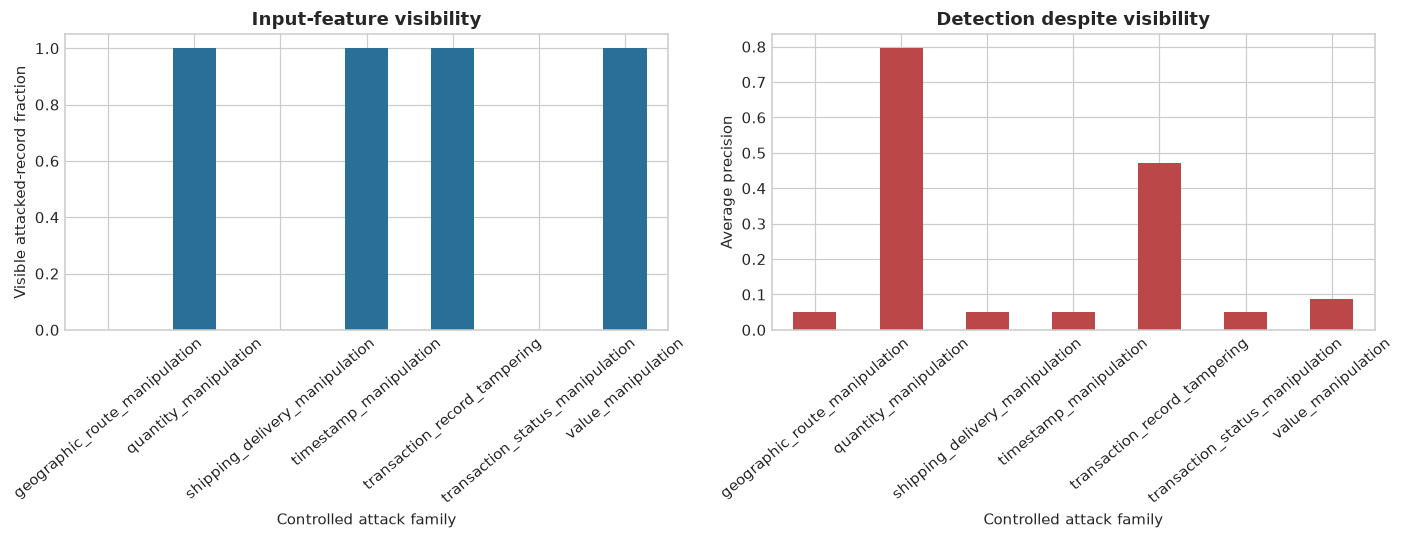

In [14]:
visibility = tables["visibility"]
baseline_visibility = visibility[
    (visibility["classifier"] == "decision_tree")
    & (visibility["configuration_id"] == "none_natural")
    & (visibility["metric"] == "selected_feature_visibility_rate")
    & (visibility["attack_type"] != "mixed")
].set_index("attack_type")["mean"].sort_index()
baseline_family_ap = family_ap["none_natural"].reindex(baseline_visibility.index)

timestamp_visibility = baseline_visibility.loc["timestamp_manipulation"]
timestamp_ap = baseline_family_ap.loc["timestamp_manipulation"]
timestamp_recall = attack_family[
    (attack_family["classifier"] == "decision_tree")
    & (attack_family["configuration_id"] == "none_natural")
    & (attack_family["attack_type"] == "timestamp_manipulation")
    & (attack_family["metric"] == "recall")
]["mean"].iloc[0]
assert timestamp_visibility == 1.0

visibility_table = pd.DataFrame(
    {"visibility_rate": baseline_visibility, "average_precision": baseline_family_ap}
)
display(visibility_table)
print(
    f"Timestamp example: visibility={timestamp_visibility:.2f}, "
    f"AP={timestamp_ap:.4f}, recall={timestamp_recall:.4f}."
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
baseline_visibility.plot(kind="bar", ax=axes[0], color="#2a6f97")
axes[0].set(xlabel="Controlled attack family", ylabel="Visible attacked-record fraction", title="Input-feature visibility")
baseline_family_ap.plot(kind="bar", ax=axes[1], color="#bc4749")
axes[1].set(xlabel="Controlled attack family", ylabel="Average precision", title="Detection despite visibility")
for ax in axes:
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

## 19. Feature-Selection Stability

Deterministic unsupervised selected sets were invariant across seeds. MI and ANOVA-F depended on seed-specific supervised attack labels. The locked MI K11 set had moderate pairwise Jaccard stability rather than a single universal composition. This variability is part of the result and was not removed through post hoc consensus selection.

,configuration,jaccard,jaccard_min,jaccard_max,pair_count
10,Full baseline,1.000000,1.000,1.000000,10.0
32,Pairwise correlation,1.000000,1.000,1.000000,10.0
98,MI K=11,0.567097,0.375,0.692308,10.0


,feature_common_to_all_five_MI_K11_sets
0,is_weekend
1,order_item_quantity
2,order_item_total
3,product_price
4,year


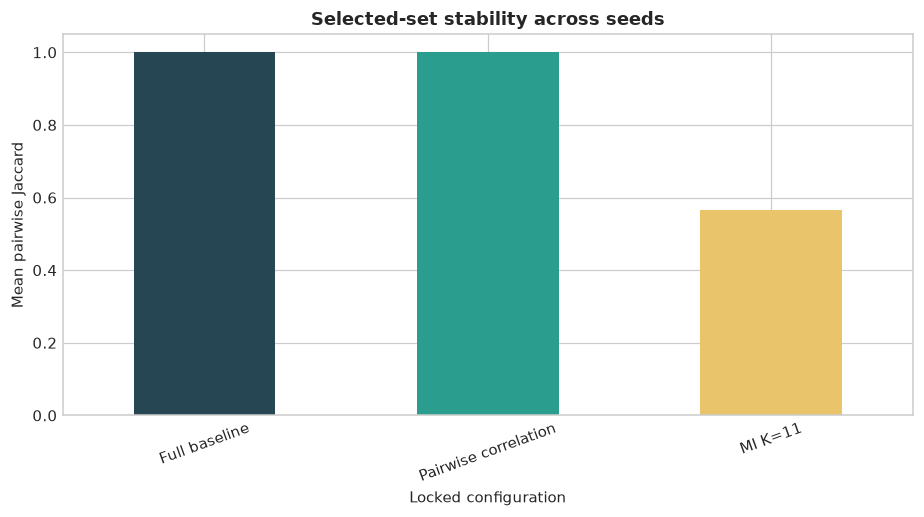

In [15]:
stability = tables["selected_set_stability"]
stability_summary = stability[
    (stability["comparison_type"] == "summary") & stability["configuration_id"].isin(locked_ids)
][["configuration_id", "jaccard", "jaccard_min", "jaccard_max", "pair_count"]].copy()
stability_summary.insert(1, "configuration", stability_summary["configuration_id"].map(labels))

selected_sets = list(documents["selected_feature_sets"].values())
mi_sets = [set(item["selected_features"]) for item in selected_sets if item["configuration_id"] == "mutual_information_select_k_best_k11"]
mi_common = sorted(set.intersection(*mi_sets))
assert len(mi_sets) == 5

display(stability_summary.drop(columns="configuration_id"))
display(pd.DataFrame({"feature_common_to_all_five_MI_K11_sets": mi_common}))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_stability = stability_summary.set_index("configuration")["jaccard"]
plot_stability.plot(kind="bar", ax=ax, color=["#264653", "#2a9d8f", "#e9c46a"])
ax.set(xlabel="Locked configuration", ylabel="Mean pairwise Jaccard", ylim=(0, 1.05), title="Selected-set stability across seeds")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 20. Computational Resource Analysis

V0.6 measures feature count, selector/model/combined fit time, inference time, per-record latency, process RSS, selected-input size, and serialized model size where available. These are **computational proxies, not electrical-energy measurements**.

The stages use different scopes. V0.6-D validation includes selector and model fitting. V0.6-F uses fresh-process repeated inference with model loading excluded. V0.6-G measures already-loaded models in the current robustness process and has a much larger process RSS. The tables are therefore kept separate rather than pooled.

V0.6-D validation scope: selector + Decision Tree fitting and short validation inference


,configuration,feature_count_mean,training_sec_mean,inference_sec_mean,peak_rss_mib_mean,model_size_bytes_mean
0,Full baseline,43.0,0.176427,0.005140,286.218750,4132.0
2,Pairwise correlation,42.0,1.396547,0.004984,296.414844,4116.0
8,MI K=11,11.0,4.298620,0.005274,296.655469,3402.4


V0.6-F final-test scope: fresh-process Decision Tree inference, 6,000 records


metric,configuration,selected_feature_count,inference_wall_time_sec,per_record_latency_us,peak_rss_mib,serialized_model_kib
0,Full baseline,43.0,0.023610,3.935019,153.074219,4.035156
1,Pairwise correlation,42.0,0.030598,5.099745,152.925781,4.019531
2,MI K=11,11.0,0.026925,4.487459,150.804688,3.322656


V0.6-G primary robustness scope: current process, models already loaded


metric,classifier,configuration_id,configuration,inference_wall_time_sec,model_fit_wall_time_sec,peak_rss_mib,per_record_inference_sec,selected_input_bytes,serialized_model_bytes
0,decision_tree,mutual_information_select_k_best_k11,MI K=11,0.001869,NaN,805.546875,3.114244e-07,528132.0,3402.4
1,decision_tree,none_natural,Full baseline,0.004545,NaN,805.325000,7.574937e-07,2064132.0,4132.0
2,decision_tree,pairwise_correlation_filter_natural,Pairwise correlation,0.002476,NaN,805.556250,4.127179e-07,2016132.0,4116.0
3,logistic_regression,mutual_information_select_k_best_k11,MI K=11,0.001506,0.274977,805.570312,2.510153e-07,528132.0,1353.2
4,logistic_regression,none_natural,Full baseline,0.002486,0.490018,805.730469,4.143751e-07,2064132.0,2342.0
5,logistic_regression,pairwise_correlation_filter_natural,Pairwise correlation,0.002119,0.522619,805.542969,3.532348e-07,2016132.0,2310.0


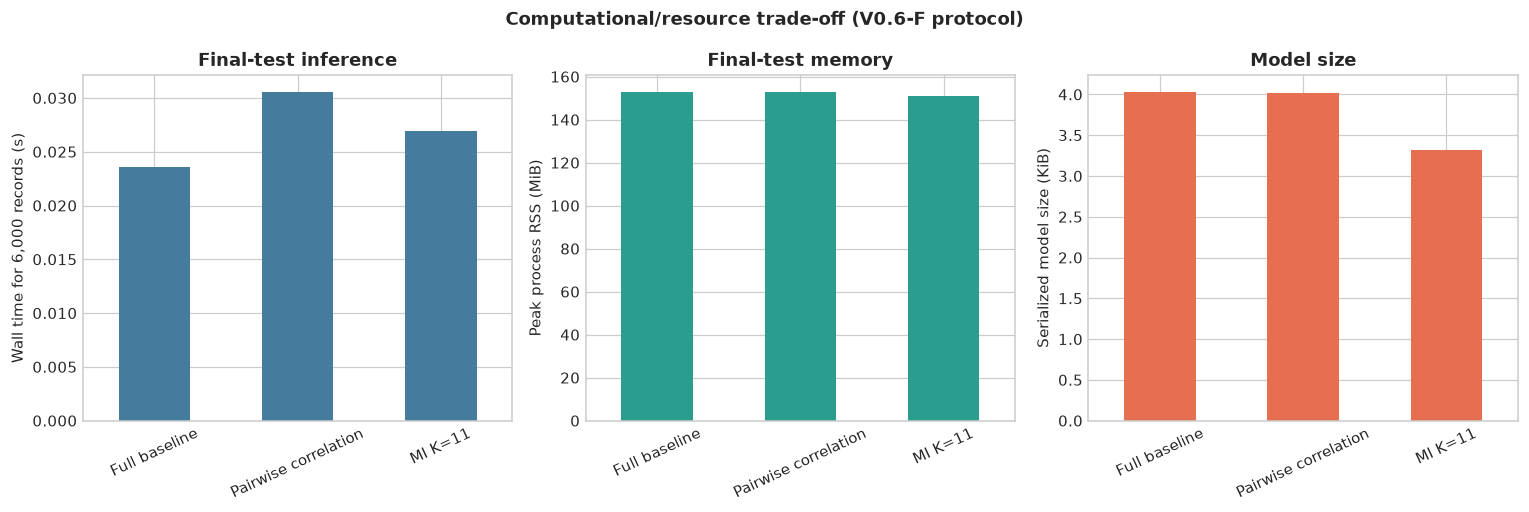

In [16]:
validation_resources = tables["validation_resources"]
final_resources = tables["final_resources"]
robustness_resources = tables["robustness_resources"]

validation_locked_resources = validation_resources[validation_resources["configuration_id"].isin(locked_ids)][
    ["configuration_id", "feature_count_mean", "training_sec_mean", "inference_sec_mean", "peak_rss_mib_mean", "model_size_bytes_mean"]
].copy()
validation_locked_resources.insert(1, "configuration", validation_locked_resources["configuration_id"].map(labels))

final_resource_wide = final_resources.pivot(index="configuration_id", columns="metric", values="mean").loc[locked_ids].reset_index()
final_resource_wide.insert(1, "configuration", final_resource_wide["configuration_id"].map(labels))
final_resource_wide["per_record_latency_us"] = final_resource_wide["inference_wall_time_sec"] / 6000 * 1_000_000
final_resource_wide["serialized_model_kib"] = final_resource_wide["serialized_model_bytes"] / 1024

primary_robustness_resources = robustness_resources[
    (robustness_resources["scenario_id"] == "mixed__r0p05__medium")
    & robustness_resources["configuration_id"].isin(locked_ids)
    & robustness_resources["metric"].isin(
        ["model_fit_wall_time_sec", "inference_wall_time_sec", "per_record_inference_sec", "peak_rss_mib", "selected_input_bytes", "serialized_model_bytes"]
    )
]
primary_robustness_wide = primary_robustness_resources.pivot(
    index=["classifier", "configuration_id"], columns="metric", values="mean"
).reset_index()
primary_robustness_wide.insert(2, "configuration", primary_robustness_wide["configuration_id"].map(labels))

print("V0.6-D validation scope: selector + Decision Tree fitting and short validation inference")
display(validation_locked_resources.drop(columns="configuration_id"))
print("V0.6-F final-test scope: fresh-process Decision Tree inference, 6,000 records")
display(
    final_resource_wide[
        ["configuration", "selected_feature_count", "inference_wall_time_sec", "per_record_latency_us", "peak_rss_mib", "serialized_model_kib"]
    ]
)
print("V0.6-G primary robustness scope: current process, models already loaded")
display(primary_robustness_wide)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
resource_plot = final_resource_wide.set_index("configuration")
resource_plot["inference_wall_time_sec"].plot(kind="bar", ax=axes[0], color="#457b9d")
axes[0].set(ylabel="Wall time for 6,000 records (s)", xlabel="", title="Final-test inference")
resource_plot["peak_rss_mib"].plot(kind="bar", ax=axes[1], color="#2a9d8f")
axes[1].set(ylabel="Peak process RSS (MiB)", xlabel="", title="Final-test memory")
resource_plot["serialized_model_kib"].plot(kind="bar", ax=axes[2], color="#e76f51")
axes[2].set(ylabel="Serialized model size (KiB)", xlabel="", title="Model size")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("Computational/resource trade-off (V0.6-F protocol)", fontweight="bold")
plt.tight_layout()
plt.show()

## 21. Preservation Analysis

Pairwise correlation descriptively preserves all V0.6-G scenarios for both classifiers. MI K11 preserves the primary final-test case but not every robustness scenario. Decision Tree MI failures include several invisible/weak families and LOW-severity mixed attacks. Logistic Regression MI has additional failures. Preservation is scenario- and classifier-dependent; no robustness result was used to change the validation lock.

,classifier,configuration,sum,count,preserved_fraction
0,decision_tree,MI K=11,8,13,0.615385
1,decision_tree,Pairwise correlation,13,13,1.000000
2,logistic_regression,MI K=11,6,13,0.461538
3,logistic_regression,Pairwise correlation,13,13,1.000000


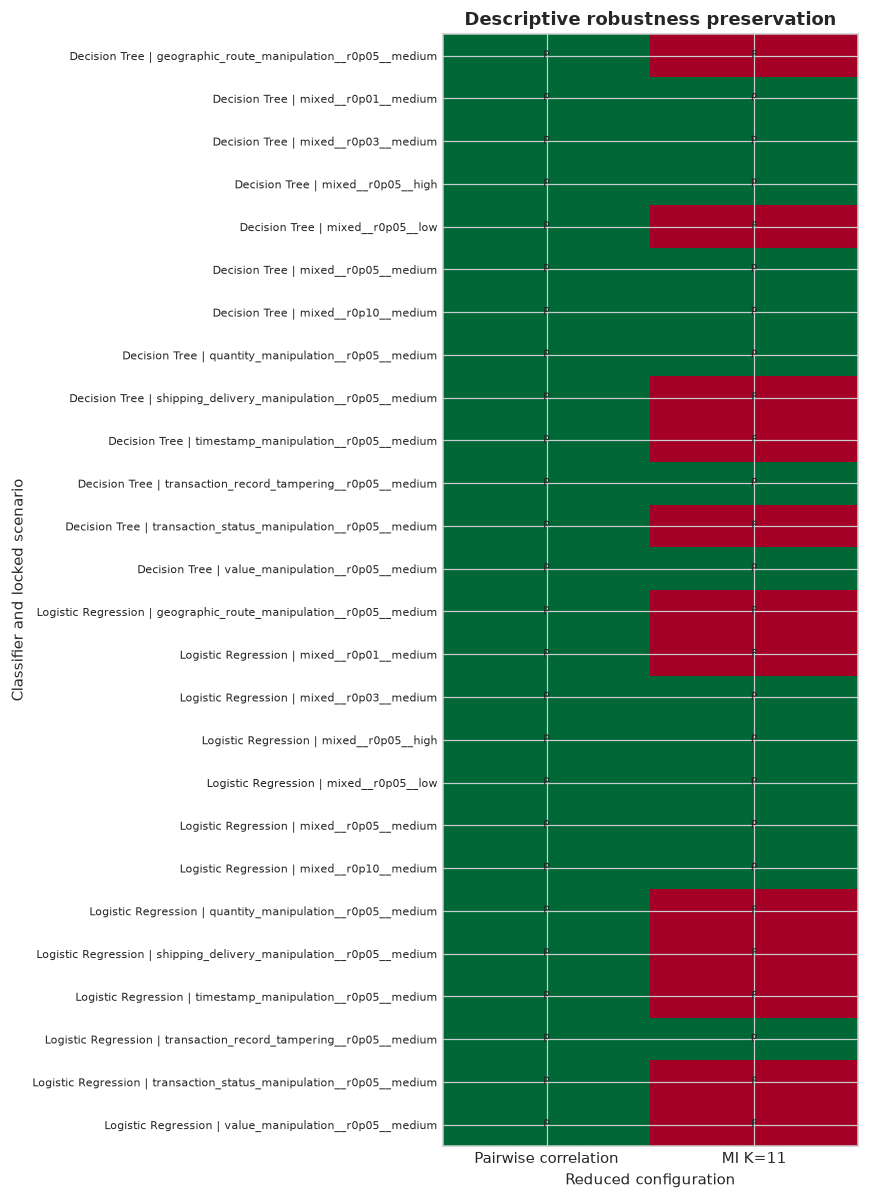

In [17]:
robustness_preservation = tables["robustness_preservation"]
scenario_preservation = robustness_preservation[
    robustness_preservation["configuration_id"].isin(locked_ids[1:])
][
    ["scenario_id", "attack_type", "attack_rate", "attack_severity", "classifier", "configuration_id", "scenario_configuration_preserved", "selection_performed"]
].drop_duplicates()

assert not scenario_preservation["selection_performed"].any()
pairwise_rows = scenario_preservation[scenario_preservation["configuration_id"] == "pairwise_correlation_filter_natural"]
assert pairwise_rows["scenario_configuration_preserved"].all()

preservation_counts = (
    scenario_preservation.groupby(["classifier", "configuration_id"])["scenario_configuration_preserved"]
    .agg(["sum", "count"])
    .reset_index()
)
preservation_counts["preserved_fraction"] = preservation_counts["sum"] / preservation_counts["count"]
preservation_counts["configuration"] = preservation_counts["configuration_id"].map(labels)
display(preservation_counts[["classifier", "configuration", "sum", "count", "preserved_fraction"]])

heatmap_data = scenario_preservation.copy()
heatmap_data["row"] = heatmap_data["classifier"].str.replace("_", " ").str.title() + " | " + heatmap_data["scenario_id"]
heatmap_data["column"] = heatmap_data["configuration_id"].map(labels)
heatmap = heatmap_data.pivot(index="row", columns="column", values="scenario_configuration_preserved")
heatmap = heatmap[["Pairwise correlation", "MI K=11"]]

fig, ax = plt.subplots(figsize=(8, 11))
image = ax.imshow(heatmap.astype(int), aspect="auto", cmap=plt.cm.RdYlGn, vmin=0, vmax=1)
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns)
ax.set_yticks(range(len(heatmap.index)), heatmap.index, fontsize=7)
ax.set(xlabel="Reduced configuration", ylabel="Classifier and locked scenario", title="Descriptive robustness preservation")
for row in range(len(heatmap.index)):
    for column in range(len(heatmap.columns)):
        ax.text(column, row, "P" if heatmap.iloc[row, column] else "F", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()

## 22. Key Figures

The notebook has regenerated eight presentation views exclusively from locked tables:

1. Validation feature count versus average precision.
2. Final-test feature count versus AP, F1, and recall with 95% intervals.
3. Robustness by attack family.
4. Performance versus attack rate.
5. Performance versus attack severity.
6. Attack visibility versus detection.
7. Decision Tree versus Logistic Regression.
8. Preservation and computational/resource trade-offs.

The inventory below identifies existing pipeline-generated figures available for independent visual cross-checking. No source figure is modified.

In [18]:
existing_figures = sorted(
    path.relative_to(PROJECT_ROOT)
    for folder in [RESULTS_ROOT / "figures", FINAL_ROOT / "figures", ROBUSTNESS_ROOT / "figures"]
    for path in folder.glob("*.png")
)
display(pd.DataFrame({"existing_locked_figure": [str(path) for path in existing_figures]}))

,existing_locked_figure
0,results/feature_selection/figures/validation_a...
1,results/feature_selection/figures/validation_t...
2,results/feature_selection/final_test/figures/f...
3,results/feature_selection/final_test/figures/i...
4,results/feature_selection/robustness/figures/a...
5,results/feature_selection/robustness/figures/d...
6,results/feature_selection/robustness/figures/f...
7,results/feature_selection/robustness/figures/f...
8,results/feature_selection/robustness/figures/p...
9,results/feature_selection/robustness/figures/r...


## 23. Scientific Interpretation

**Experimental fact:** MI K11 reduced the candidate feature count from 43 to 11 (74.42%) and met the preregistered validation and final-test descriptive preservation margins.

**Experimental fact:** Final-test MI-minus-baseline confidence intervals for AP, F1, and recall all cross zero. V0.6 does not establish statistical superiority.

**Experimental fact:** The full baseline and pairwise-correlation configuration produced effectively identical Decision Tree predictions while pairwise filtering removed only one feature.

**Interpretation:** MI K11 is the strongest classical dimensionality-reduction baseline, but its seed-dependent feature composition and scenario-specific robustness failures qualify deployment claims.

**Interpretation:** Attack representation is a first-order limitation. Invisible attacks cannot induce model response through the frozen input space, while timestamp manipulation shows that representation alone does not ensure separability or useful detection.

**Interpretation:** Logistic Regression often increases recall while producing very low precision/AP, so higher recall alone is not evidence of better overall cybersecurity effectiveness.

## 24. Limitations

1. Controlled modifications are not native cyber incidents, and DataCo is not a dedicated cybersecurity dataset.
2. The study uses one deterministic data split and five seeds; confidence intervals cover seed variability only.
3. Descriptive preservation margins are not formal non-inferiority tests.
4. AP, precision, and F1 change with attack prevalence, complicating rate-panel comparisons.
5. The 43-feature baseline excludes leakage-prone and unavailable raw fields, causing zero visibility for some attacks.
6. Feature visibility measures whether engineered inputs changed, not whether those changes are learnable.
7. MI K11 feature identities vary across seeds; no post hoc consensus set was constructed.
8. The Decision Tree is primary and Logistic Regression is an untuned secondary comparator; results do not cover broader model families.
9. Resource measurements use different process scopes across V0.6-D/F/G and cannot be pooled.
10. Runtime, RSS, input bytes, and model size are computational proxies, not measured electrical energy.
11. Modest absolute AP, F1, and recall prohibit claims of production-ready cybersecurity detection.

## 25. V0.6 Conclusions

V0.6 answers its narrow research question affirmatively but conditionally. Classical mutual-information selection reduced the frozen feature space by about 74.42% while preserving preregistered mean performance margins on validation and final test. This establishes MI K11 as a defensible reduced classical baseline for later optimization.

The conclusion is not that detection became statistically better or operationally sufficient. Absolute final-test detection remained modest, paired intervals did not establish improvement, the exact MI subset varied by seed, and preservation did not hold across every robustness scenario. Feature visibility emerged as necessary but insufficient: attacks omitted from the engineered feature space cannot be induced-detected, while visible timestamp manipulation remained difficult.

V0.6 therefore contributes a leakage-controlled, locked, reproducible feature-reduction baseline and an honest map of its cybersecurity limits.

In [19]:
baseline_final_ap = final_perf.set_index("configuration_id").loc["none_natural", "average_precision"]
mi_final_ap = final_perf.set_index("configuration_id").loc["mutual_information_select_k_best_k11", "average_precision"]
conclusion_evidence = pd.DataFrame(
    {
        "claim": [
            "Feature reduction",
            "Baseline final-test AP",
            "MI K11 final-test AP",
            "MI K11 final-test preservation",
            "MI paired AP/F1/recall CIs cross zero",
            "Robustness matrix complete",
            "Electrical energy directly measured",
        ],
        "artifact-verified value": [
            f"{feature_reduction:.2f}% (43 -> 11)",
            f"{baseline_final_ap:.6f}",
            f"{mi_final_ap:.6f}",
            bool(mi_preservation["overall_descriptive_preservation"].all()),
            True,
            f"{robustness_metadata['completed_run_count']}/{robustness_metadata['expected_run_count']}",
            False,
        ],
    }
)
display(conclusion_evidence)

,claim,artifact-verified value
0,Feature reduction,74.42% (43 -> 11)
1,Baseline final-test AP,0.222084
2,MI K11 final-test AP,0.224941
3,MI K11 final-test preservation,True
4,MI paired AP/F1/recall CIs cross zero,True
5,Robustness matrix complete,390/390
6,Electrical energy directly measured,False


## 26. Relationship to V0.7, V0.8, V0.9 and V1.0

- **V0.7:** applies a separate Green AI measurement protocol. V0.6 contributes computational proxies only and makes no electrical-energy claim.
- **V0.8:** introduces BPSO against the immutable 43-feature and classical reduced baselines.
- **V0.9:** introduces BGWO under the same data, model, metric, and leakage contract.
- **V1.0:** evaluates the proposed hybrid/multi-objective framework, integrated Blockchain-AI architecture, scalability, and final ablations.

The reusable feature-selector contract and locked V0.6 roles prevent later optimizers from receiving an easier baseline or changing test governance. Later stages must compare against both the full 43-feature baseline and MI K11, account for optimizer-search cost, and keep direct energy distinct from computational proxies.

---

**Reproducibility status:** all values and figures above derive from repository-relative, pre-existing V0.6 CSV/JSON artifacts. This notebook performs documentation, assertions, descriptive reshaping, and plotting only.